# Avance 4. Modelos alternativos

DOMÉNICO MORALES ORTIZ 		A00820324

MÓNICA DODERO ARROYO		    A01795330

OSCAR ANTONIO SUÁREZ V 	    A01323987

INSTITUTO TECNOLÓGICO Y DE ESTUDIOS SUPERIORES DE MONTERREY
TC5035 - Proyecto Integrador

Dra. Grettel Barceló Alonso

Dr. Luis Eduardo Falcón Morales

Mtra. Verónica Sandra Guzmán de Valle

## Instalación de módulos y referencias de librerías

In [ ]:
!pip install astropy
!pip install kaggle
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 68.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
from google.colab import userdata
import os
import cv2
import json
import torch
import shutil
import kagglehub
import random
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
from PIL import Image
from pathlib import Path
import ultralytics
import matplotlib.pyplot as plt
from collections import defaultdict
from torchvision import transforms
from astropy.io import fits
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from ultralytics import YOLO
from skimage.feature import canny
from skimage.filters import unsharp_mask
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from astropy.visualization import ZScaleInterval, LogStretch, MinMaxInterval, LinearStretch
from astropy.visualization import make_lupton_rgb
from sklearn.decomposition import PCA

In [ ]:
### Colab
# Se necesita montar el drive y acceder a la carpeta donde están los archivos
drive.mount('/content/drive')

# Cargar variables de entorno en colab
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Descargar los datos
# Lista de los datasets disponibles:
# - domenicomoralesortiz/ls-dr10-224-gri-262-rgi-stack
# - domenicomoralesortiz/ls-dr10-224-gri-262-rgi-lognorm-stack
# - domenicomoralesortiz/ls-dr10-224-gri-262-rgi-unsharp-mask
# - domenicomoralesortiz/ls-dr10-224-gri-262-pca-stack
# - domenicomoralesortiz/ls-dr10-224-gri-262-rgi-canny-stack

# Lista con tupla (Kaggle link, folder)
datasets = [("domenicomoralesortiz/ls-dr10-224-gri-262-rgi-stack", "ls_dr10_224_gri_262_rgi_stack"),
            ("domenicomoralesortiz/ls-dr10-224-gri-262-rgi-lognorm-stack", "ls_dr10_224_gri_262_rgi_lognorm_stack"),
            ("domenicomoralesortiz/ls-dr10-224-gri-262-rgi-unsharp-mask", "ls_dr10_224_gri_262_rgi_unsharp_mask"),
            ("domenicomoralesortiz/ls-dr10-224-gri-262-pca-stack", "ls_dr10_224_gri_262_pca_stack"),
            ("domenicomoralesortiz/ls-dr10-224-gri-262-rgi-canny-stack", "ls_dr10_224_gri_262_rgi_canny_stack")]

datasets_dict = {}

for kagglehub_link, folder in datasets:
  path = kagglehub.dataset_download(kagglehub_link)
  datasets_dict[folder] = path
  print(f"Path to {folder} dataset files:", path)

Mounted at /content/drive


100%|██████████| 402M/402M [00:19<00:00, 21.8MB/s]

Extracting files...


Path to ls_dr10_224_gri_262_rgi_stack dataset files: /root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-rgi-stack/versions/1


100%|██████████| 588M/588M [00:27<00:00, 22.1MB/s]

...

Extracting files...


Path to ls_dr10_224_gri_262_pca_stack dataset files: /root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-pca-stack/versions/1


100%|██████████| 52.9M/52.9M [00:03<00:00, 15.1MB/s]

Extracting files...


Path to ls_dr10_224_gri_262_rgi_canny_stack dataset files: /root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-rgi-canny-stack/versions/1


In [ ]:
# Direcciones a partir de la descarga
DOWNLOAD_PATHS = {}
DATA_PATHS = {}
CSV_PATHS = {}
for folder, path in datasets_dict.items():
  DOWNLOAD_PATHS[folder] = Path(path) / folder
  DATA_PATHS[folder] = DOWNLOAD_PATHS[folder] / "data"
  CSV_PATHS[folder] = DOWNLOAD_PATHS[folder] / "lsdr10_paths.csv"

print("DATA path:", DATA_PATHS)
print("CSV path:", CSV_PATHS)

DATA path: {'ls_dr10_224_gri_262_rgi_stack': PosixPath('/root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-rgi-stack/versions/1/ls_dr10_224_gri_262_rgi_stack/data'), 'ls_dr10_224_gri_262_rgi_lognorm_stack': PosixPath('/root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-rgi-lognorm-stack/versions/1/ls_dr10_224_gri_262_rgi_lognorm_stack/data'), 'ls_dr10_224_gri_262_rgi_unsharp_mask': PosixPath('/root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-rgi-unsharp-mask/versions/1/ls_dr10_224_gri_262_rgi_unsharp_mask/data'), 'ls_dr10_224_gri_262_pca_stack': PosixPath('/root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-pca-stack/versions/1/ls_dr10_224_gri_262_pca_stack/data'), 'ls_dr10_224_gri_262_rgi_canny_stack': PosixPath('/root/.cache/kagglehub/datasets/domenicomoralesortiz/ls-dr10-224-gri-262-rgi-canny-stack/versions/1/ls_dr10_224_gri_262_rgi_canny_stack/data')}
CSV path: {'ls_dr10_224_gri_262_rgi_stack': P

## Funciones de apoyo
Este bloque se encarga de construir las funciones recurrentes en el código.

In [ ]:
# Leer el csv para obtener los tipos de anillo
df = pd.read_csv(list(CSV_PATHS.values())[0])

# Crear la variable para almacenar tipos de anillo
RING_TYPE_4C = list(df["ring_type"].unique())
#Define el caso binario: ausencia vs presencia de anillo.
RING_TYPE_2C = ["none", "ring"]

def create_dataset_folders(base_path, categories):
  """Crear las carpetas para el dataset de clasificación.

  Args:
      base_path (str): Ruta base del dataset.
      categories (list): Lista de categorías.
  """
  base_path = Path(base_path)
  os.makedirs(base_path, exist_ok=True)
  # Por cada categoría
  for category in categories:
      train_path = base_path / "train" / category
      val_path = base_path / "val" / category
      os.makedirs(train_path, exist_ok=True)
      os.makedirs(val_path, exist_ok=True)
  print(f"Carpetas del dataset creadas en: {base_path}")


def split_dataset(source_dir, base_path, categories, train_ratio=0.8, seed=None):
  """Dividir el dataset en entrenamiento y validación.

  Args:
      source_dir (str): Ruta del dataset original.
      base_path (str): Ruta base del dataset.
      categories (list): Lista de categorías.
      train_ratio (float, optional): Proporción de datos para entrenamiento.
      seed (int, optional): Semilla para la división del dataset.
  """
  np.random.seed(seed)  # Controlar la aleatoriedad
  source_dir = Path(source_dir)
  base_path = Path(base_path)

  dataset_sizes = {"previous": {}, "train": {}, "val": {}}

  # Por cada categoría
  for category in categories:
      if len(categories) == 2:
        if category == "none":
          category_files = list(source_dir.glob(f"{category}/*.png"))
        else:
          category_files = [f for f in source_dir.glob("*/*.png") if 'none' not in f.parts]
      else:
        category_files = list(source_dir.glob(f"{category}/*.png"))
      dataset_sizes["previous"][category] = len(category_files)
      np.random.shuffle(category_files) # Mezclar los datos

      # Obtener conjunto de entrenamiento
      train_size = int(len(category_files) * train_ratio)
      train_files = category_files[:train_size]
      dataset_sizes["train"][category] = len(train_files)
      # Obtener conjunto de validación
      val_files = category_files[train_size:]
      dataset_sizes["val"][category] = len(val_files)

      # Copiar las imagenes en el dataset a usar
      for file in train_files:
          dest = base_path / "train" / category / file.name
          shutil.copy(file, dest)

      for file in val_files:
          dest = base_path / "val" / category / file.name
          shutil.copy(file, dest)

  print("Dataset anterior:")
  print(dataset_sizes["previous"])
  print("Dataset train:")
  print(dataset_sizes["train"])
  print("Dataset val:")
  print(dataset_sizes["val"])

def subsample_to_max(base_path, categories, max_count=1000, seed=None):
  """Hacer una reducción de datos a las clases según el máximo indicado.

  Args:
      base_path (str): Ruta base del dataset.
      categories (list): Lista de categorías.
      max_count (int, optional): Máximo número de imágenes por clase.
      seed (int, optional): Semilla para la aleatoriedad.
  """
  np.random.seed(seed)  # Controlar la aleatoriedad
  base_path = Path(base_path)

  dataset_sizes = {"train": {}, "val": {}}

  # Por cada categoría
  for category in categories:
      train_path = base_path / "train" / category
      val_path = base_path / "val" / category

      train_files = list(train_path.glob("*.png"))
      val_files = list(val_path.glob("*.png"))

      # Si los datos de entrenamiento sobrepasan el máximo
      if len(train_files) > max_count:
          # Eliminar el excedente
          files_to_remove = np.random.choice(train_files, len(train_files) - max_count, replace=False)
          for file in files_to_remove:
              os.remove(file)

      dataset_sizes["train"][category] = len(list(train_path.glob("*.png")))

      # Si los datos de validación sobrepasan el máximo
      if len(val_files) > max_count:
          # Eliminar el excedente
          files_to_remove = np.random.choice(val_files, len(val_files) - max_count, replace=False)
          for file in files_to_remove:
              os.remove(file)

      dataset_sizes["val"][category] = len(list(val_path.glob("*.png")))

  print("Dataset train:")
  print(dataset_sizes["train"])
  print("Dataset val:")
  print(dataset_sizes["val"])

class AugmentedDataset(Dataset):
  """Dataset personalizado para el aumento de datos empatando a la clase mayoritaria."""
  def __init__(self, root_dir, categories, transform=None, target_count=None, seed=42, balance=False):
      np.random.seed(seed)
      self.root_dir = Path(root_dir)  # Ruta de los datos
      self.transform = transform      # Conjunto de transformaciones a aplicar
      self.samples = []               # Todas las imágenes
      self.labels = []                # Todas las etiquetas
      self.class_to_idx = {cat: i for i, cat in enumerate(categories)}
      self.idx_to_class = {i: cat for cat, i in self.class_to_idx.items()}

      # Dict {categoría: [lista de rutas de imágenes]}
      class_files = {cat: list(f for f in self.root_dir.glob(f"{cat}/*.png"))
                      for cat in categories}

      # Si no hay máximo especificado, se toma la categoría mayoritaria
      if target_count is None:
          target_count = max(len(files) for files in class_files.values())

      if balance:
        # Por cada imagen de cada categoría
        for cat, files in class_files.items():
            current_count = len(files)
            # Si el número de imágenes no es igual al número máximo
            if current_count < target_count:
                # Obtener un conjunto de imágenes para repetir para alcanzar
                augmentations_needed = target_count - current_count
                augmented_files = np.random.choice(files, augmentations_needed, replace=True)
                files.extend(augmented_files)
            # Si es mayor, elegir un conjunto del número máximo
            elif current_count > target_count:
                files = np.random.choice(files, target_count, replace=False).tolist()

            # Acumular datos y etiquetas
            self.samples.extend(files)
            self.labels.extend([self.class_to_idx[cat]] * len(files))
      else:
        # Por cada categoría
        for cat, files in class_files.items():
            # Acumular datos y etiquetas
            self.samples.extend(files)
            self.labels.extend([self.class_to_idx[cat]] * len(files))

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
    """Función para obtener un elemento del dataset."""
    img_path = self.samples[idx]
    image = Image.open(img_path).convert('RGB') # Ensure image is in RGB
    label = self.labels[idx]

    if self.transform:
        image = self.transform(image)

    return image, label

  def __str__(self):
    """Función para imprimir información del dataset."""
    class_counts = defaultdict(int)
    for label in self.labels:
        class_counts[self.idx_to_class[label]] += 1
    return f"AugmentedDataset with {len(self)} samples\n" + \
            "\n".join([f"{cls}: {count}" for cls, count in class_counts.items()])

def visualize_augmented_images(dataloader, ring_classes):
  """Visualizar imágenes aumentadas."""
  dataiter = iter(dataloader)
  images, labels = next(dataiter)

  plt.subplots(4, 5, figsize=(20, 10))
  for i in range(20):
      plt.subplot(4, 5, i + 1)
      title = ring_classes[labels[i]]
      img = images[i].numpy().transpose((1, 2, 0))  # Convertir de Tensor a numpy
      mean = np.array([0.485, 0.456, 0.406])
      std = np.array([0.229, 0.224, 0.225])
      img = std * img + mean  # Regresar de la normalización
      img = np.clip(img, 0, 1)  # Clip
      plt.imshow(img)
      plt.title(title + str(i))
      plt.axis('off')
  plt.suptitle('Ejemplo de imagenes aumentadas con las que se entrenó el modelo')
  plt.tight_layout()
  plt.show()

## Creación de datasets

In [ ]:
"""
Automatiza la creación de datasets derivados a partir de múltiples transformaciones
y configuraciones de clases (binario y multiclase).
"""
for folder, data_path in DATA_PATHS.items():
  transformation = folder.split("262_")[-1]
  print("="*20, transformation, "="*20)
  for num_class, ring_type in [(2, RING_TYPE_2C), (4, RING_TYPE_4C)]:
    create_dataset_folders(f"dataset_{transformation}_{num_class}", ring_type)
    split_dataset(DATA_PATHS[folder], f"dataset_{transformation}_{num_class}", ring_type, train_ratio=0.8)
    subsample_to_max(f"dataset_{transformation}_{num_class}", ring_type, max_count=1000, seed=42)

==================== rgi_stack ====================
Carpetas del dataset creadas en: dataset_rgi_stack_2
Dataset anterior:
{'none': 6646, 'ring': 1409}
Dataset train:
{'none': 5316, 'ring': 1127}
Dataset val:
{'none': 1330, 'ring': 282}
Dataset train:
{'none': 1000, 'ring': 1000}
Dataset val:
{'none': 1000, 'ring': 282}
Carpetas del dataset creadas en: dataset_rgi_stack_4
Dataset anterior:
{'none': 6646, 'inner': 853, 'inner+outer': 370, 'outer': 186}
Dataset train:
{'none': 5316, 'inner': 682, 'inner+outer': 296, 'outer': 148}
Dataset val:
{'none': 1330, 'inner': 171, 'inner+outer': 74, 'outer': 38}
Dataset train:
{'none': 1000, 'inner': 682, 'inner+outer': 296, 'outer': 148}
Dataset val:
{'none': 1000, 'inner': 171, 'inner+outer': 74, 'outer': 38}
==================== rgi_lognorm_stack ====================
Carpetas del dataset creadas en: dataset_rgi_lognorm_stack_2
Dataset anterior:
{'none': 6646, 'ring': 1409}
Dataset train:
{'none': 5316, 'ring': 1127}
Dataset val:
{'none': 1330, 

## Dataloaders

Al haber creado diferentes datasets tanto para clases binarias (hay/no hay anillo) se realiza las siguientes transformaciones para el subconjunto de datos de entrenamiento:

En principal, estamos delimitando el número máximo de imágenes por clase. Así como aplicar aumentar la diversidad de nuestro dataset sin necesidad de recolectar más datos con transformaciones tales como:

Espejo Horizontal/Vertical
Rotar por ángulos y rellenar
Reescalar los valores de píxeles a estadísticas que el modelo YOLOv11 conoce, centrando los valores de cada canal alrededor a 0
Hacer un desenfoque Gaussiano
Sin embargo, para nuestro subconjunto de validación para no agregar sesgo al modelo o también pasar por un proceso llamado "data leakage". Adicionalmente, con un parametro con balance=True para empatar clases a la mayoritaria.

Dataset: /content/dataset_rgi_stack_2
Classes: ['none', 'ring']
AugmentedDataset with 2000 samples
none: 1000
ring: 1000
AugmentedDataset with 1282 samples
none: 1000
ring: 282


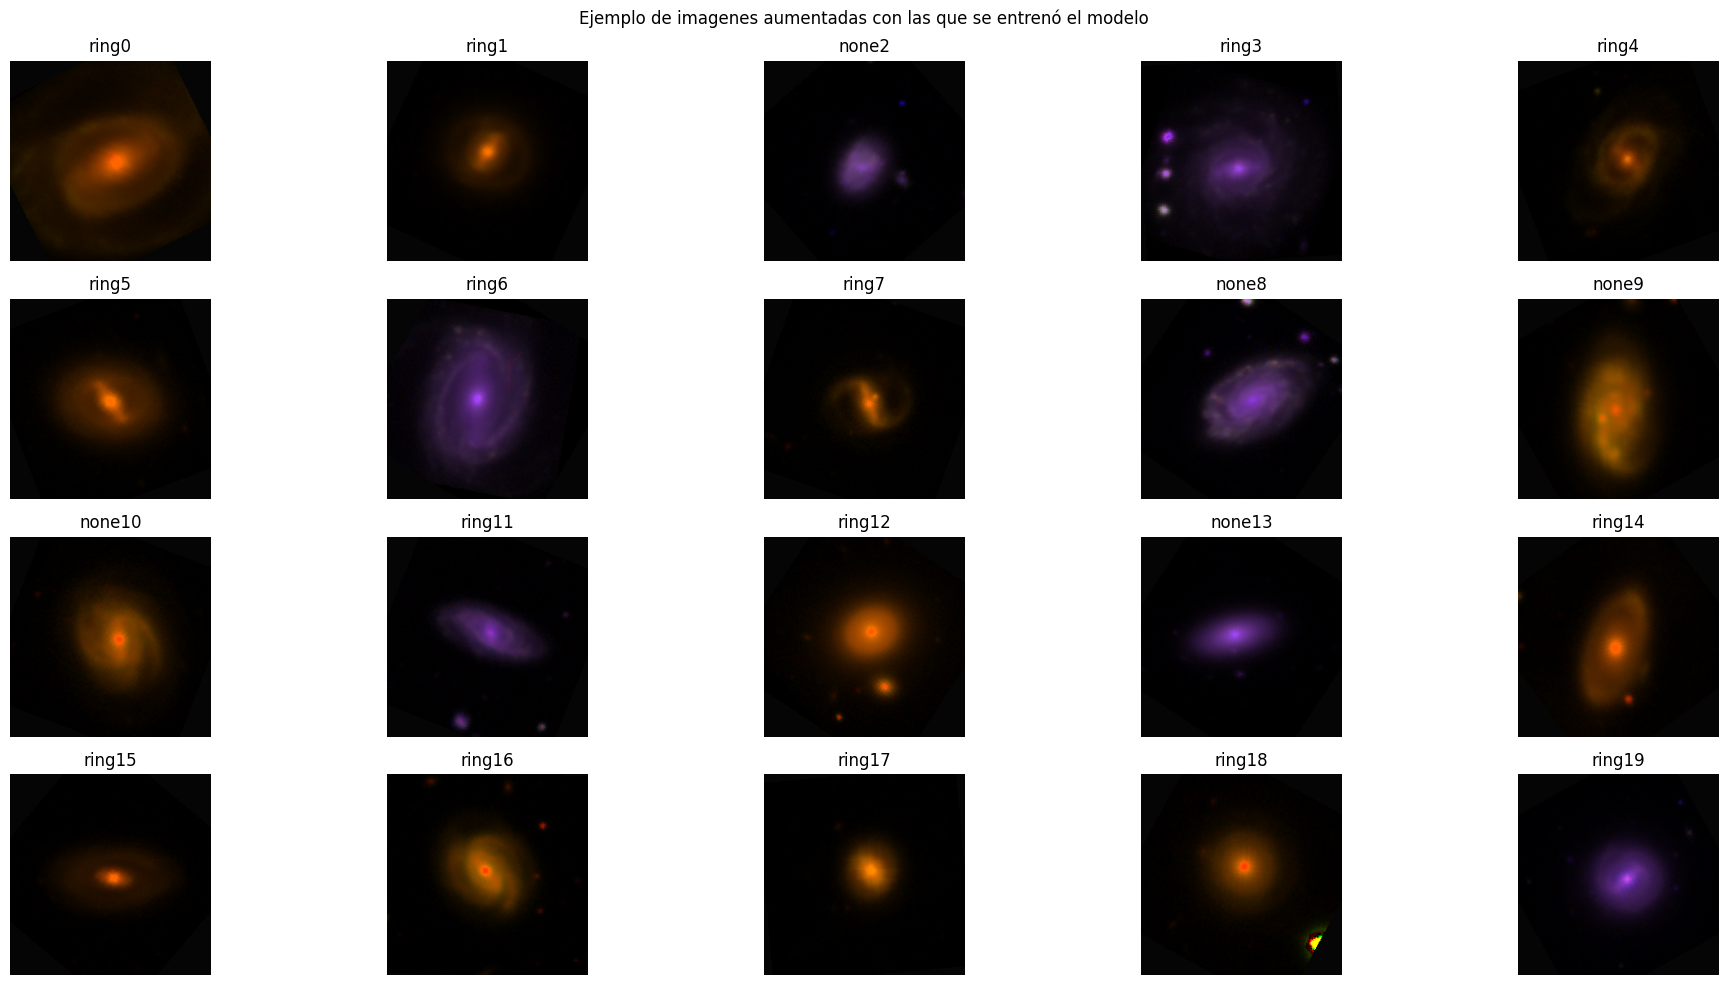

In [ ]:
"""
Configura el dataset a utilizar, define las transformaciones de entrenamiento y validación,
crea los objetos Dataset y DataLoader, y finalmente visualiza ejemplos de imágenes aumentadas.
"""

#Selección del dataset y de las clases a usar (binario o multiclase) según lo creado anteriormente
dataset_to_use = Path("/content/dataset_rgi_stack_2")
ring_type = RING_TYPE_2C

print("Dataset:", dataset_to_use)
print("Classes:", ring_type)

#Definición de transformaciones,  incluye augmentations (flips, affine, blur, rotación) + conversión a tensor + normalización
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=20, translate=(0.05,0.05), scale=(0.9,1.1), shear=5, fill=0),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5)], p=0.3),
    transforms.RandomRotation(180, fill=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#No realizamos estos pasos para no tener una fuga de datos
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#Creación de los DataLoaders, en donde - train_dataloader con shuffle=True para mezclar datos en cada época | - val_dataloader con shuffle=False para evaluación estable.
train_dataset = AugmentedDataset(f"{str(dataset_to_use)}/train", ring_type, transform=train_transform, target_count=None, balance=True)
val_dataset = AugmentedDataset(f"{str(dataset_to_use)}/val", ring_type, transform=val_transform, target_count=None)

if len(ring_type) == 2:
  train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
  val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
else:
  train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
  val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print(train_dataset)
print(val_dataset)

visualize_augmented_images(train_dataloader, ring_type)

## Construcción de modelos y sus funciones

El entrenamiento consta de 3 fases:

Fase 1: solo head. El head es la última parte de la red, la capa de clasificación que convierte las features en predicciones de clases. Esto nos sirve para adaptar la salida del modelo sin perder lo que ya sabía en su etapa de preentrenamiento

Fase 2: head + bloque anterior (attention). Se “descongela” también el bloque inmediatamente anterior al head, que suele ser un bloque de attention o de features de alto nivel. Ahora el modelo ajusta no solo la capa final, sino también las representaciones más cercanas a la salida.

Fase 3: head + attention + backbone completo. Finalmente se descongela todo el backbone (todas las capas convolucionales iniciales y medias).Ahora el modelo puede reajustar desde las features más básicas (bordes, texturas) hasta las más abstractas. Finalmente, esto puede ser una capa de doble filo porque el hecho que el dataset sea pequeño puede incurrir a un overfitting

Es por ese motivo, y después de distintas pruebas con un problema de multidimensionalidad de clases, se decide definir solo dos clases: [none, ring]

Estamos utilizando weight_decay=1e-4: que penaliza pesos grandes para evitar overfitting. ReduceLROnPlateau (modo “max”): scheduler, que reduce el learning rate cuando la métrica monitorizada deja de mejorar. Aquí la métrica es el f1-score de la clase “ring”, “max” significa que se espera que la métrica aumente; si no sube tras cierto número de épocas (patience), baja el lr a la mitad (factor=0.5)

En cada época, se evalúa en el conjunto de validación.

Se usa classification_report de sklearn, la cual nos da precision, recall, f1-score por clase y global. Se guarda el modelo solo si el f1-score de “ring” mejora respecto al mejor anterior.

Esto es clave, ya que nos evita que el modelo solo se optimice solo para la clase mayoritaria (“none”) y garantiza que se priorice la clase minoritaria (“ring”), que es la que estamos interesados.

In [ ]:
class YOLOs_2CLS(nn.Module):
    """
Clase YOLOs_2CLS: Adaptación de un modelo YOLO preentrenado para clasificación binaria
('none' vs 'ring') con un head personalizado.

Características principales:
    - Carga un modelo YOLO de clasificación preentrenado.
    - Modifica la última capa (head) para salida binaria con Dropout y Linear(…, 1).
    - Usa BCEWithLogitsLoss para entrenamiento estable en binario.
    - Entrenamiento progresivo por fases:
        Fase 1: solo head.
        Fase 2: head + bloque anterior (attention).
        Fase 3: head + attention + backbone completo.
    - Optimización con Adam + weight decay.
    - Scheduler ReduceLROnPlateau monitorizando f1-score de la clase 'ring'.
    - Guarda el mejor modelo según f1-score de 'ring'.
    - Evaluación con búsqueda de umbral óptimo para maximizar f1-score.

Métodos:
    __init__(): Inicializa modelo, head, hiperparámetros y scheduler.
    load_model(path): Carga un modelo previamente guardado.
    __str__(): Imprime información del modelo y del dispositivo.
    train_model(train_loader, val_loader, ...): Entrena el modelo por fases,
        calcula métricas y guarda el mejor checkpoint.
    evaluation(val_loader, ...): Evalúa el modelo, busca el mejor umbral,
        imprime classification_report y genera matriz de confusión.
        """
  def __init__(self, model=YOLO('yolo11s-cls.pt').model):
    super().__init__()
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.model = model.to(self.device)
    self.model.to(self.device)
    self.ring_type = ["none", "ring"]
    # Model configuration
    self.model.model[-1].drop = nn.Dropout(p=0.4)
    self.model.model[-1].linear = nn.Linear(model.model[-1].linear.in_features, 1)
    # Training hyperparameters
    self.num_epochs = 15
    self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.0001, weight_decay=1e-4)
    self.criterion = torch.nn.BCEWithLogitsLoss()
    self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', factor=0.5, patience=5)

  def forward(self, x):
    return self.model(x)

  def load_model(self, path):
    self.model = torch.load(str(path), weights_only=False, map_location=self.device)

  def __str__(self):
    print("Modelo de 2 clases: ['none', 'ring']")
    print("Usando el device:", self.device)
    print("Head:\n", self.model.model[-1])
    return ""

  def train_model(self, train_loader, val_loader, epochs=None, fase=1, return_history=False):
        """
Entrena el modelo YOLO adaptado para clasificación binaria ('none' vs 'ring')
siguiendo un esquema de fases de fine-tuning.

Args:
    train_loader (DataLoader): Cargador de datos de entrenamiento.
    val_loader (DataLoader): Cargador de datos de validación.
    epochs (int, optional): Número de épocas de entrenamiento
    fase (int, optional): fase de entrenamiento (1, 2, 3).
    return_history (bool, optional): si True, devuelve también el historial de métricas.
"""

    self.model.to(self.device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    num_epochs = epochs if epochs is not None else self.num_epochs
    for param in self.model.parameters():
      param.requires_grad = False
    if fase == 1:
      print("Entrenando Head...")
      for param in self.model.model[-1].parameters():
        param.requires_grad = True
    elif fase == 2:
      print("Entrenando Head | Attention...")
      for param in self.model.model[-2].parameters():
        param.requires_grad = True
      for param in self.model.model[-1].parameters():
        param.requires_grad = True
    elif fase == 3:
      print("Entrenando Head | Attention | Backbone...")
      for param in self.model.model[-3].parameters():
        param.requires_grad = True
      for param in self.model.model[-2].parameters():
        param.requires_grad = True
      for param in self.model.model[-1].parameters():
        param.requires_grad = True
    else:
      print("Entrenando Head...")
      for param in self.model.model[-1].parameters():
        param.requires_grad = True

#Loop de entrenamiento
    for epoch in range(num_epochs):
      self.model.train()
      running_loss = 0.0
      correct = 0
      total = 0
      for param_group in self.optimizer.param_groups:
          print("LR:", param_group['lr'])
      for i, (images, labels) in enumerate(train_dataloader):
          print(f"{i+1}/{len(train_dataloader)}", end='\r')
          images, labels = images.to(self.device), labels.to(self.device)

          self.optimizer.zero_grad()

          outputs = self.model(images)
          # print("train", outputs.shape, labels.shape)
          outputs = outputs.squeeze(1)
          labels = labels.float()
          loss = self.criterion(outputs, labels)
          loss.backward()
          self.optimizer.step()

          running_loss += loss.item() * images.size(0)
          preds = (torch.sigmoid(outputs) > 0.5).long()
          correct += (preds == labels).sum().item()
          total += labels.size(0)

      epoch_loss = running_loss / total
      epoch_acc = correct / total
      history["train_loss"].append(epoch_loss)
      history["train_acc"].append(epoch_acc)
      print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

      # Validación, calcula loss y accuracy. Guarda all_labels y all_preds para métricas.
      self.model.eval()
      running_loss = 0.0
      correct = 0
      total = 0
      all_labels = []
      all_preds = []
      with torch.no_grad():
          for images, labels in val_dataloader:
              images, labels = images.to(self.device), labels.to(self.device)
              outputs = self.model(images)
              if isinstance(outputs, tuple):
                  outputs = outputs[1]
              outputs = outputs.squeeze(1)
              labels = labels.float()
              loss = self.criterion(outputs, labels)
              running_loss += loss.item() * images.size(0)
              preds = (torch.sigmoid(outputs) > 0.5).long()
              all_labels.extend(labels.cpu().numpy())
              all_preds.extend(preds.cpu().numpy())

              correct += (preds == labels).sum().item()
              total += labels.size(0)
#Calcula loss y accuracy promedio por época.
#Guarda en historial para utilizar luego.
      epoch_loss = running_loss / total
      val_accuracy = correct / total
      history["val_loss"].append(epoch_loss)
      history["val_acc"].append(val_accuracy)

      print(f"Validation Loss: {epoch_loss:.4f}, Accuracy: {val_accuracy:.4f}")
      cm = classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
      print("ring class metrics:", cm['ring'])

      self.scheduler.step(cm['ring']['f1-score'])

      if epoch == 0:
          best_ring_f1 = cm['ring']['f1-score']
          torch.save(self.model, f'best_model_e{epoch}_f1{best_ring_f1*100:.0f}.pt')

      else:
          if cm['ring']['f1-score'] > best_ring_f1:
              best_ring_f1 = cm['ring']['f1-score']
              torch.save(self.model, f'best_model_e{epoch}_f1{best_ring_f1*100:.0f}.pt')
              print("Model saved with ring f1-score: ", best_ring_f1)

    if return_history:
      return self.model, history
    else:
      return self.model

  def evaluation(self, val_dataloader, use_best_th=True, th=None, ax=None):#return_fig=False):
    self.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[1]
            preds = (torch.sigmoid(outputs) > 0.5).long()
            all_probs.extend(outputs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    probs_all = np.array(all_probs)
    labels_all = np.array(all_labels)

    ths = np.linspace(0.01, 0.99, 99)
    best_f1 = 0
    best_th = 0.9
    for th in ths:
        preds = (probs_all >= th).astype(int)
        f1 = f1_score(labels_all, preds, pos_label=1)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    if use_best_th:
      all_preds = (probs_all >= best_th).astype(int)
      print("Using best threshold:", best_th)
    elif th is not None:
      all_preds = (probs_all >= th).astype(int)
      print("Using threshold:", th)
    print("Classification Report:")
    # Generar la matriz de confusión
    conf_matrix = confusion_matrix(all_labels, all_preds)
    if ax:
      sns.heatmap(conf_matrix, annot=True, fmt='.0f', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', ax=ax, cbar=False)
      return classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
    else:
      print(classification_report(all_labels, all_preds, target_names=self.ring_type))
      fig, ax = plt.subplots(figsize=(10, 8))
      sns.heatmap(conf_matrix, annot=True, fmt='.0f', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', cbar=False)
      ax.set_xlabel('Predicted')
      ax.set_ylabel('True')
      ax.set_title('Confusion Matrix')
      print("Confusion Matrix:")
      plt.show()
      return None

  def get_activation(self, name):
    self.activation = {}
    def hook(model, input, output):
        self.activation[name] = output.detach()
    return hook

  def get_attention(self):
    return self.model.model[-2].register_forward_hook(self.get_activation('att_layer')) # pull attention



class YOLOs_4CLS(nn.Module):
  """
Clase YOLOs_4CLS: Adaptación de un modelo YOLO preentrenado para clasificación
en 4 clases de galaxias con anillos: ['none', 'inner', 'inner+outer', 'outer'].

Características principales:
    - Carga un modelo YOLO de clasificación preentrenado.
    - Modifica la última capa (head) para salida multiclase.
    - Añade Dropout (0.2) para regularización.
    - Usa CrossEntropyLoss con label smoothing (0.1) para suavizar etiquetas
      y mejorar la generalización.
    - Optimiza con Adam + weight decay.
    - Scheduler ReduceLROnPlateau monitorizando métricas de evaluación.

Métodos:
    __init__(): Inicializa modelo, head, hiperparámetros y scheduler.
    forward(x): Pasa un batch de imágenes por el modelo.
    load_model(path): Carga un modelo previamente guardado.
    __str__(): Imprime información del modelo y del dispositivo.
    train_model(...): Entrena el modelo por fases, calcula métricas y guarda historial.
"""
  def __init__(self, model=YOLO('yolo11s-cls.pt').model):
    super().__init__()
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.model = model.to(self.device)
    self.model.to(self.device)
    self.ring_type = ['none', 'inner', 'inner+outer', 'outer']
    # Model configuration
    self.model.model[-1].drop = nn.Dropout(p=0.2)
    self.model.model[-1].linear = nn.Linear(model.model[-1].linear.in_features, 4)
    # Training hyperparameters
    self.num_epochs = 15
    #Label smoothing (0.1): evita que el modelo se confíe demasiado en una sola clase.
    self.criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
    self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.0001, weight_decay=1e-4)
    self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', factor=0.5, patience=5)

  def forward(self, x):
    return self.model(x)

  def load_model(self, path):
    self.model = torch.load(str(path), weights_only=False, map_location=self.device)

  def __str__(self):
    print("Modelo de 4 clases: ['none', 'inner', 'inner+outer', 'outer']")
    print("Usando el device:", self.device)
    print("Head:\n", self.model.model[-1])
    return ""

  def train_model(self, train_loader, val_loader, epochs=None, fase=1, return_history=False):
    self.model.to(self.device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    num_epochs = epochs if epochs is not None else self.num_epochs
    for param in self.model.parameters():
      param.requires_grad = False
    if fase == 1:
      print("Entrenando Head...")
      for param in self.model.model[-1].parameters():
        param.requires_grad = True
    elif fase == 2:
      print("Entrenando Head | Attention...")
      for param in self.model.model[-2].parameters():
        param.requires_grad = True
      for param in self.model.model[-1].parameters():
        param.requires_grad = True
    elif fase == 3:
      print("Entrenando Head | Attention | Backbone...")
      for param in self.model.model[-3].parameters():
        param.requires_grad = True
      for param in self.model.model[-2].parameters():
        param.requires_grad = True
      for param in self.model.model[-1].parameters():
        param.requires_grad = True
    else:
      print("Entrenando Head...")
      for param in self.model.model[-1].parameters():
        param.requires_grad = True


    for epoch in range(num_epochs):
      self.model.train()
      running_loss = 0.0
      correct = 0
      total = 0
      for param_group in self.optimizer.param_groups:
          print("LR:", param_group['lr'])
      for i, (images, labels) in enumerate(train_dataloader):
          print(f"{i+1}/{len(train_dataloader)}", end='\r')
          images, labels = images.to(self.device), labels.to(self.device)

          self.optimizer.zero_grad()

          outputs = self.model(images)
          # print("train", outputs.shape, labels.shape)
          loss = self.criterion(outputs, labels)
          loss.backward()
          self.optimizer.step()

          running_loss += loss.item() * images.size(0)
          _, preds = torch.max(outputs, 1)
          correct += (preds == labels).sum().item()
          total += labels.size(0)

#Calcula loss y accuracy promedio por época.
#Guarda en historial para utilizar luego.
      epoch_loss = running_loss / total
      epoch_acc = correct / total
      history["train_loss"].append(epoch_loss)
      history["train_acc"].append(epoch_acc)
      print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

      # Validación
      self.model.eval()
      running_loss = 0.0
      correct = 0
      total = 0
      all_labels = []
      all_preds = []
      with torch.no_grad():
          for images, labels in val_dataloader:
              images, labels = images.to(self.device), labels.to(self.device)
              outputs = self.model(images)
              if isinstance(outputs, tuple):
                  outputs = outputs[0]
              loss = self.criterion(outputs, labels)
              running_loss += loss.item() * images.size(0)
              _, preds = torch.max(outputs, 1)
              all_labels.extend(labels.cpu().numpy())
              all_preds.extend(preds.cpu().numpy())

              correct += (preds == labels).sum().item()
              total += labels.size(0)

      epoch_loss = running_loss / total
      val_accuracy = correct / total
      history["val_loss"].append(epoch_loss)
      history["val_acc"].append(val_accuracy)
      print(f"Validation Loss: {epoch_loss:.4f}, Accuracy: {val_accuracy:.4f}")

      cm = classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
      for i, cls in enumerate(self.ring_type):
          print(f"Class {cls} f1-score: {cm[cls]['f1-score']:.4f}")

      f1_scores = [cm[cls]['f1-score'] for cls in self.ring_type if cls != 'none']
      mean_f1 = np.mean(f1_scores)
      print(f"Mean f1-score (excluding 'none'): {mean_f1:.4f}")

      self.scheduler.step(mean_f1)

      if epoch == 0:
          best_rings_f1 = mean_f1
          torch.save(self.model, f'best_model_e{epoch}_f1{mean_f1*100:.0f}.pt')
      else:
          if mean_f1 > best_rings_f1:
              best_rings_f1 = mean_f1
              torch.save(self.model, f'best_model_e{epoch}_f1{mean_f1*100:.0f}.pt')
              print("Model saved with f1-score: ", best_rings_f1)

    if return_history:
      return self.model, history
    else:
      return self.model

  def evaluation(self, val_dataloader, return_fig=False, ax=None):
    self.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    probs_all = np.array(all_probs)
    labels_all = np.array(all_labels)

    print("Classification Report:")
    # Generar la matriz de confusión
    conf_matrix = confusion_matrix(all_labels, all_preds)
    if ax:
      sns.heatmap(conf_matrix, annot=True, fmt='.0f', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', ax=ax, cbar=False)
      return classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
    else:
      print(classification_report(all_labels, all_preds, target_names=self.ring_type))
      fig, ax = plt.subplots(figsize=(10, 8))
      sns.heatmap(conf_matrix, annot=True, fmt='.0f', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', cbar=False)
      ax.set_xlabel('Predicted')
      ax.set_ylabel('True')
      ax.set_title('Confusion Matrix')
      print("Confusion Matrix:")
      plt.show()
      return None

  def get_activation(self, name):
    self.activation = {}
    def hook(model, input, output):
        self.activation[name] = output.detach()
    return hook

  def get_attention(self):
    return self.model.model[-2].register_forward_hook(self.get_activation('att_layer')) # pull attention

#Iniciarlizar una instancia para nuestro objeto - modelo.
model = YOLOs_2CLS()

#Imprimimos las configuraciones personalizada
print(model)

Modelo de 2 clases: ['none', 'ring']
Usando el device: cuda
Head:
 Classify(
  (conv): Conv(
    (conv): Conv2d(512, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (drop): Dropout(p=0.4, inplace=False)
  (linear): Linear(in_features=1280, out_features=1, bias=True)
)



## Métricas y resultados

Debido a que nos centramos en colocar nuestra mirada en un problema binario (presencia o no de anillos) Existe un patrón general y ese es que clase mayoritaria (“none”), siempre con alta precisión y recall. Mas, la clase minoritaria estuvo mucho más dificil. Esto refleja el desbalance de clases y la dificultad intrínseca de detectar anillos. Y, aunque el accuracy en general está alto, puede llegar a ser engañoso porque lo domina la clase mayoritaria AÚN con todos los procesos de balanceo aplicados, el verdadero reto está en mejorar el recall de “ring”. Sin embargo, se denota un crece de todas las transformaciones utilizando el preprocesamiento de "Canny" en los resultados, entendemos que hay una leve diferencia en correr estos procesos de manera local vs nube.

En esta sección se muestra cómo se comportan los modelos bajo cada transformación y carpeta en Drive: cada corrida deja su matriz de confusión y su reporte, y el F1 ponderado se convierte en la brújula para comparar. Así notamos que el preprocesamiento unsharp, al realzar bordes y contrastes, ensancha la brecha entre galaxias con y sin anillos, reforzando el F1 de “ring” y justificando que lo tomemos como referencia al reportar resultados y balancear precisión con exhaustividad.

La comparación entre el esquema binario y el multiclase confirma una mejora con dos etiquetas: los modelos “ring vs. none” sostienen F1 ponderados arriba de 0.81, mientras que las cuatro categorías caen a 0.69–0.75. Concentrar la decisión en detectar anillos reduce confusiones entre etiquetas, preserva una precisión global estable y, sobre todo, impulsa la sensibilidad hacia la clase minoritaria que buscamos resaltar.

==================== dataset_rgi_stack_2
Loading trained model with F1 score on ring class: 59
Using threshold: 0.99
Classification Report:
{'none': {'precision': 0.874031007751938, 'recall': 0.902, 'f1-score': 0.8877952755905512, 'support': 1000.0}, 'ring': {'precision': 0.608, 'recall': 0.5390070921985816, 'f1-score': 0.5714285714285714, 'support': 282.0}, 'accuracy': 0.8221528861154446, 'macro avg': {'precision': 0.7410155038759689, 'recall': 0.7205035460992908, 'f1-score': 0.7296119235095613, 'support': 1282.0}, 'weighted avg': {'precision': 0.8155124865459734, 'recall': 0.8221528861154446, 'f1-score': 0.8182044717109269, 'support': 1282.0}}
==================== dataset_rgi_canny_stack_2
Loading trained model with F1 score on ring class: 57
Using threshold: 0.99
Classification Report:
{'none': {'precision': 0.8712406015037594, 'recall': 0.927, 'f1-score': 0.8982558139534884, 'support': 1000.0}, 'ring': {'precision': 0.6651376146788991, 'recall': 0.5141843971631206, 'f1-score': 0.58

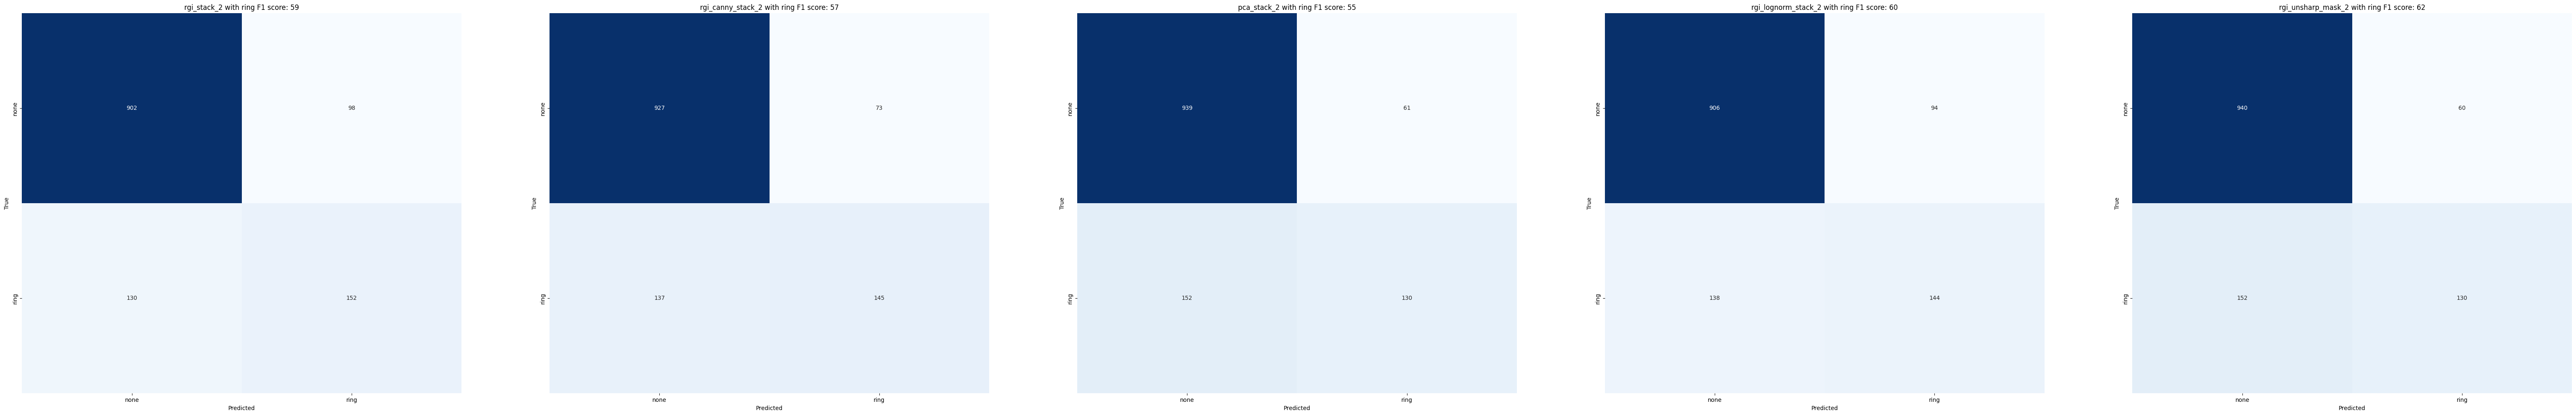

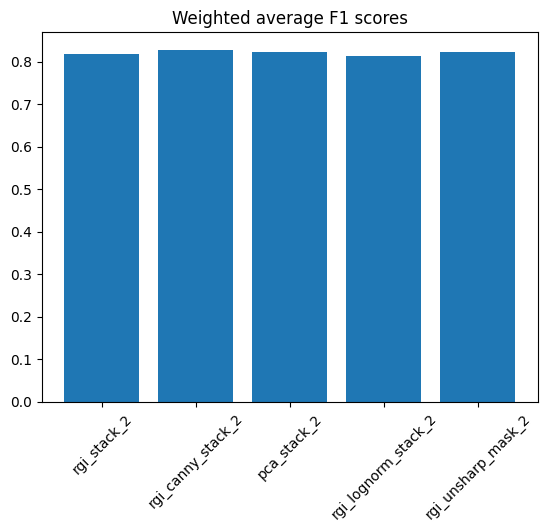

==================== dataset_rgi_stack_4
Loading trained model with F1 score on ring class: 29
Classification Report:
{'none': {'precision': 0.940337224383917, 'recall': 0.725, 'f1-score': 0.818746470920384, 'support': 1000.0}, 'inner': {'precision': 0.368, 'recall': 0.5380116959064327, 'f1-score': 0.43705463182897863, 'support': 171.0}, 'inner+outer': {'precision': 0.3949579831932773, 'recall': 0.6351351351351351, 'f1-score': 0.48704663212435234, 'support': 74.0}, 'outer': {'precision': 0.23776223776223776, 'recall': 0.8947368421052632, 'f1-score': 0.3756906077348066, 'support': 38.0}, 'accuracy': 0.6999220576773187, 'macro avg': {'precision': 0.485264361334858, 'recall': 0.6982209182867077, 'f1-score': 0.5296345856521304, 'support': 1283.0}, 'weighted avg': {'precision': 0.8117903976423887, 'recall': 0.6999220576773187, 'f1-score': 0.7356200365037132, 'support': 1283.0}}
==================== dataset_rgi_canny_stack_4
Loading trained model with F1 score on ring class: 31
Classificatio

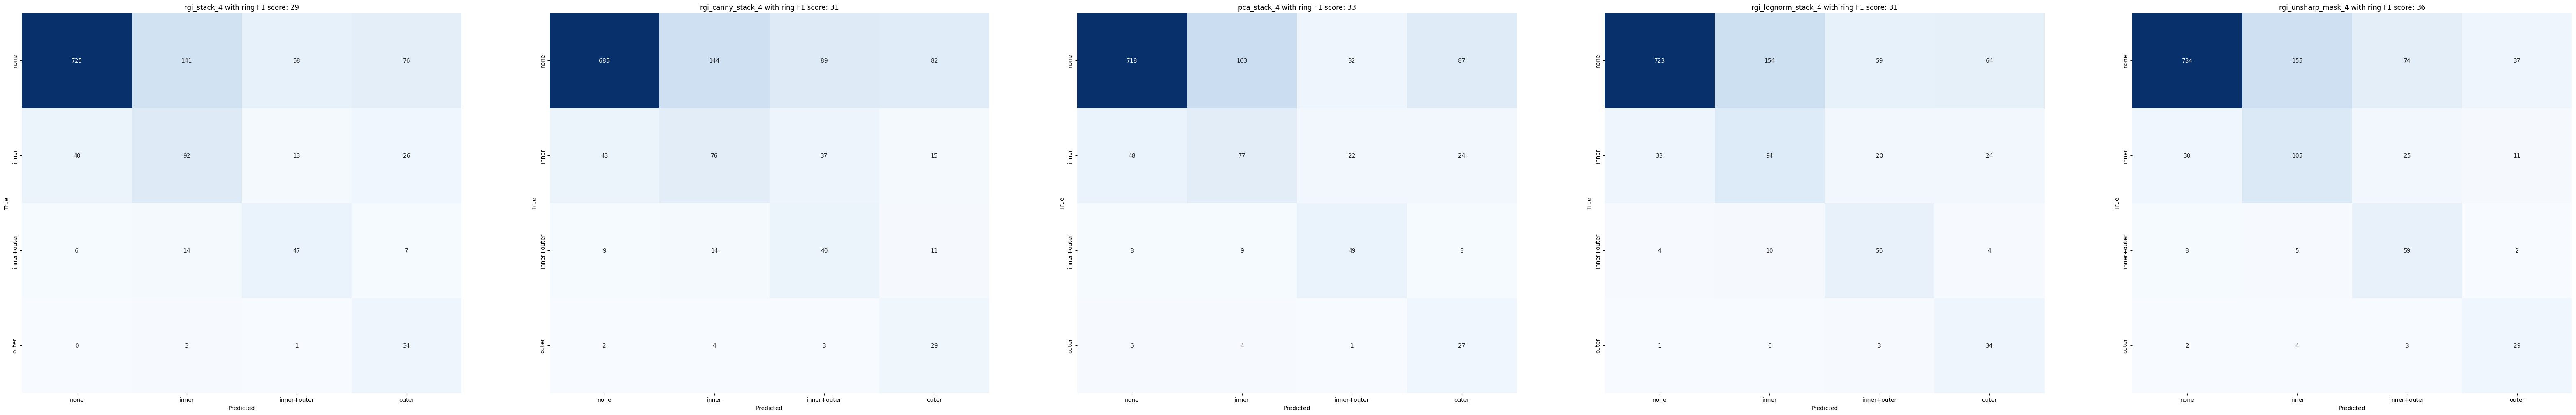

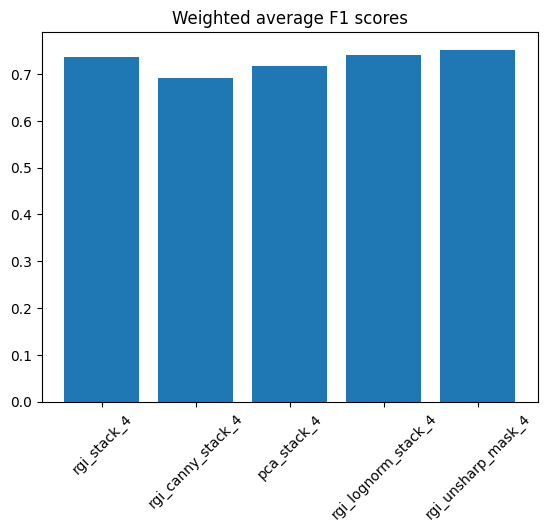

In [ ]:
path = Path("/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos")

# Imprimir matrices de confusión para los modelos de 2 clases
fig, ax = plt.subplots(1, 5, figsize=(80, 12))
i = 0
f1_scores = {'weighted_avg': []}
folders = []
for folder in path.glob("*/"):
  if folder.name.endswith("2"):
    dataset_to_use = "dataset_" + folder.name
    print("="*20, dataset_to_use)
    val_dataset = AugmentedDataset(f"{str(dataset_to_use)}/val", RING_TYPE_2C, transform=val_transform, target_count=None)
    val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    folders.append(folder.name)
    for model_path in folder.glob("*.pt"):
      model = YOLOs_2CLS()
      print("Loading trained model with F1 score on ring class:", model_path.name.split("f1")[-1].split(".")[0])
      model.load_model(model_path)
      class_report = model.evaluation(val_dataloader, ax=ax[i], use_best_th=False)
      print(class_report)
      f1_scores['weighted_avg'].append(class_report['weighted avg']['f1-score'])
      ax[i].set_title(f"{folder.name} with ring F1 score: {model_path.name.split('f1')[-1].split('.')[0]}")
      ax[i].set_xlabel('Predicted')
      ax[i].set_ylabel('True')
      i += 1
plt.show()

plt.bar(folders, f1_scores['weighted_avg'], label='weighted avg')
plt.title("Weighted average F1 scores")
plt.xticks(rotation=45)
plt.show()

# Imprimir matrices de confusión para los modelos de 4 clases
fig, ax = plt.subplots(1, 5, figsize=(80, 12))
i = 0
f1_scores = {'weighted_avg': []}
folders = []
for folder in path.glob("*/"):
  if folder.name.endswith("4"):
    dataset_to_use = "dataset_" + folder.name
    print("="*20, dataset_to_use)
    val_dataset = AugmentedDataset(f"{str(dataset_to_use)}/val", RING_TYPE_4C, transform=val_transform, target_count=None)
    val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False)
    folders.append(folder.name)
    for model_path in folder.glob("*.pt"):
      model = YOLOs_4CLS()
      print("Loading trained model with F1 score on ring class:", model_path.name.split("f1")[-1].split(".")[0])
      model.load_model(model_path)
      class_report = model.evaluation(val_dataloader, ax=ax[i])
      print(class_report)
      f1_scores['weighted_avg'].append(class_report['weighted avg']['f1-score'])
      ax[i].set_title(f"{folder.name} with ring F1 score: {model_path.name.split('f1')[-1].split('.')[0]}")
      ax[i].set_xlabel('Predicted')
      ax[i].set_ylabel('True')
      i += 1
plt.show()
plt.bar(folders, f1_scores['weighted_avg'], label='weighted avg')
plt.title("Weighted average F1 scores")
plt.xticks(rotation=45)
plt.show()



## Visualización

Aqui mostramos visualmente los mapas de activación del penúltimo bloque del modelo (hook en att_layer) para superponerlos sobre ejemplos de validación. Primero se selecciona una galaxia representativa de la clase objetivo (ring en el escenario binario y inner+outer en el multiclase); luego se propaga la imagen por cada modelo guardado, se interpola el mapa de atención al tamaño original y se fusiona con la imagen en escala de grises. 

El resultado permite observar qué regiones de la imagen concentran la atención del modelo según la transformación aplicada al dataset, facilitando interpretar si el clasificador se enfoca a la seccion correcta de la galaxia, asi se puede visualizar que dataset facilita mas la clasificacion correcta de los anillos.

==================== dataset_rgi_stack_2
Loading trained model with F1 score on ring class: 59
Index: 1231
Predicted: ring
True: ring
==================== dataset_rgi_canny_stack_2
Loading trained model with F1 score on ring class: 57
Index: 1231
Predicted: ring
True: ring
==================== dataset_pca_stack_2
Loading trained model with F1 score on ring class: 55
Index: 1231
Predicted: ring
True: ring
==================== dataset_rgi_lognorm_stack_2
Loading trained model with F1 score on ring class: 60
Index: 1231
Predicted: ring
True: ring
==================== dataset_rgi_unsharp_mask_2
Loading trained model with F1 score on ring class: 62
Index: 1231
Predicted: none
True: ring


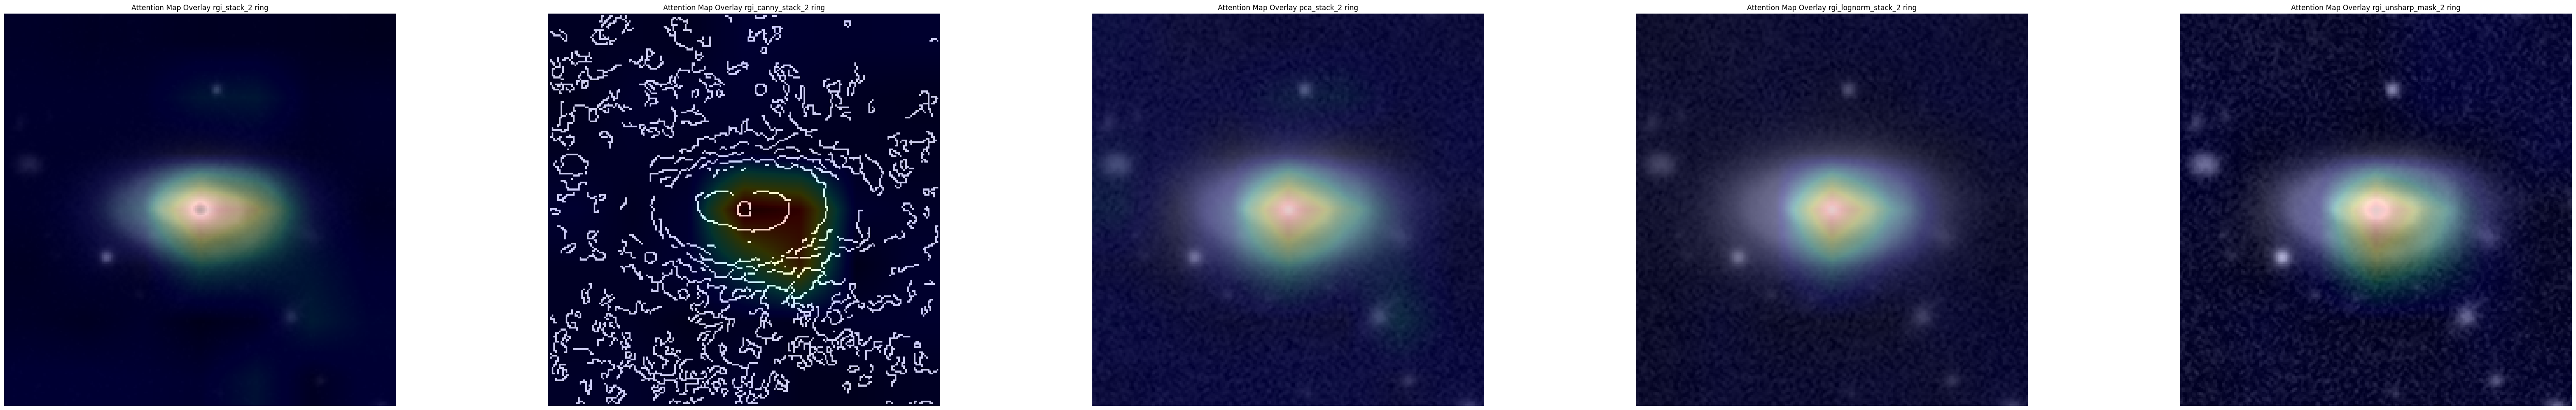

In [ ]:
layer_name = 'att_layer'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fig, ax = plt.subplots(1, 5, figsize=(80, 12))
i = 0

idx_selected = False
desired_label = 'ring'

for folder in path.glob("*/"):
  if folder.name.endswith("2"):
    dataset_to_use = "dataset_" + folder.name
    print("="*20, dataset_to_use)
    val_dataset = AugmentedDataset(f"{str(dataset_to_use)}/val", RING_TYPE_2C, transform=val_transform, target_count=None)
    if not idx_selected:
      # Find indices of images with the desired label
      desired_label_indices = [idx for idx, label in enumerate(val_dataset.labels) if val_dataset.idx_to_class[label] == desired_label]
      idx_to_visualize = random.choice(desired_label_indices)
      idx_selected = True
    folders.append(folder.name)
    for model_path in folder.glob("*.pt"):
      image, label = val_dataset[idx_to_visualize]
      images = image.unsqueeze(0).to(device)
      model = YOLOs_2CLS()
      print("Loading trained model with F1 score on ring class:", model_path.name.split("f1")[-1].split(".")[0])
      model.load_model(model_path)
      model.get_attention()
      model.eval()
      with torch.no_grad():
          outputs = model(images)

      print("Index:", idx_to_visualize)
      print("Predicted:", val_dataset.idx_to_class[torch.sigmoid(outputs[1]).item() > 0.5])
      print("True:", val_dataset.idx_to_class[label])

      feature_map = model.activation[layer_name][0].cpu()  # shape: [channels, H, W]

      attention_map = feature_map.mean(dim=0, keepdim=True)  # shape: [1, h, w]
      attention_map_upsampled = F.interpolate(attention_map.unsqueeze(0), size=images.size()[2:], mode='bilinear', align_corners=False)
      attention_map_upsampled = attention_map_upsampled.squeeze().cpu().numpy()

      mean = np.array([0.485, 0.456, 0.406])
      std = np.array([0.229, 0.224, 0.225])
      images[0] = images[0].cpu() * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
      ax[i].imshow(attention_map_upsampled, cmap='jet', alpha=1)  # alpha controls transparency
      ax[i].imshow(cv2.cvtColor(images[0].cpu().numpy().transpose(1, 2, 0), cv2.COLOR_RGB2GRAY), alpha=0.8, cmap='gray')
      ax[i].axis('off')
      ax[i].set_title(f'Attention Map Overlay {folder.name} {val_dataset.idx_to_class[label]}')
      i+=1
plt.show()

==================== dataset_rgi_stack_4
Loading trained model with F1 score on ring class: 29
(tensor([[0.0438, 0.7804, 0.1264, 0.0493]], device='cuda:0'), tensor([[-1.2464,  1.6328, -0.1872, -1.1282]], device='cuda:0'))
Index: 1178
Predicted: inner
True: inner+outer
==================== dataset_rgi_canny_stack_4
Loading trained model with F1 score on ring class: 31
(tensor([[0.0211, 0.0835, 0.8889, 0.0065]], device='cuda:0'), tensor([[-0.7978,  0.5780,  2.9431, -1.9746]], device='cuda:0'))
Index: 1178
Predicted: inner+outer
True: inner+outer
==================== dataset_pca_stack_4
Loading trained model with F1 score on ring class: 33
(tensor([[0.1360, 0.3744, 0.4788, 0.0108]], device='cuda:0'), tensor([[ 0.4233,  1.4359,  1.6817, -2.1136]], device='cuda:0'))
Index: 1178
Predicted: inner+outer
True: inner+outer
==================== dataset_rgi_lognorm_stack_4
Loading trained model with F1 score on ring class: 31
(tensor([[0.0561, 0.0896, 0.8204, 0.0340]], device='cuda:0'), tensor([[-

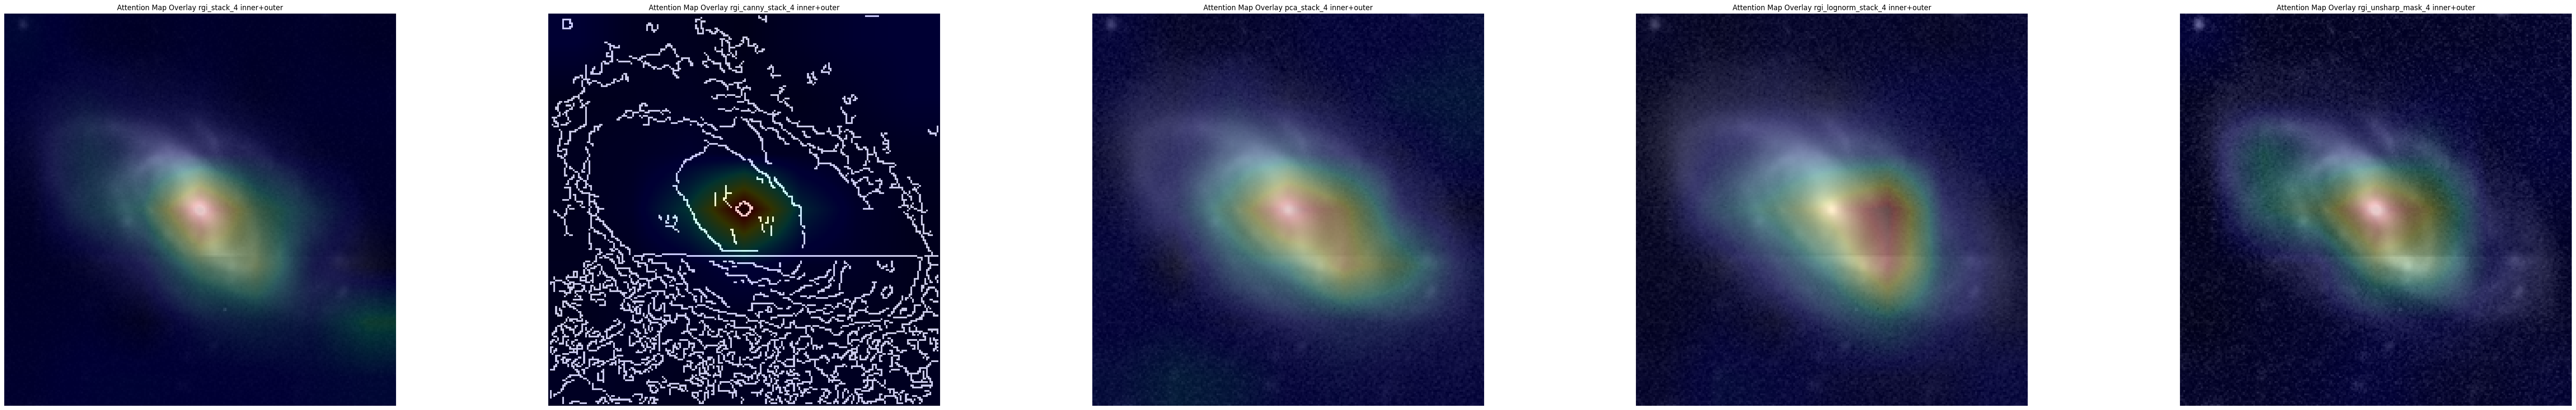

In [ ]:
layer_name = 'att_layer'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fig, ax = plt.subplots(1, 5, figsize=(80, 12))
i = 0

idx_selected = False
desired_label = 'inner+outer'

for folder in path.glob("*/"):
  if folder.name.endswith("4"):
    dataset_to_use = "dataset_" + folder.name
    print("="*20, dataset_to_use)
    val_dataset = AugmentedDataset(f"{str(dataset_to_use)}/val", RING_TYPE_4C, transform=val_transform, target_count=None)
    if not idx_selected:
      # Find indices of images with the desired label
      desired_label_indices = [idx for idx, label in enumerate(val_dataset.labels) if val_dataset.idx_to_class[label] == desired_label]
      idx_to_visualize = random.choice(desired_label_indices)
      idx_selected = True
    # val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    folders.append(folder.name)
    for model_path in folder.glob("*.pt"):
      image, label = val_dataset[idx_to_visualize]
      images = image.unsqueeze(0).to(device)
      model = YOLOs_4CLS()
      print("Loading trained model with F1 score on ring class:", model_path.name.split("f1")[-1].split(".")[0])
      model.load_model(model_path)
      model.get_attention()
      model.eval()
      with torch.no_grad():
          outputs = model(images)

      print(outputs)
      print("Index:", idx_to_visualize)
      print("Predicted:", val_dataset.idx_to_class[torch.argmax(outputs[0], 1).item()])
      print("True:", val_dataset.idx_to_class[label])

      feature_map = model.activation[layer_name][0].cpu()  # shape: [channels, H, W]

      attention_map = feature_map.mean(dim=0, keepdim=True)  # shape: [1, h, w]
      attention_map_upsampled = F.interpolate(attention_map.unsqueeze(0), size=images.size()[2:], mode='bilinear', align_corners=False)
      attention_map_upsampled = attention_map_upsampled.squeeze().cpu().numpy()

      mean = np.array([0.485, 0.456, 0.406])
      std = np.array([0.229, 0.224, 0.225])
      images[0] = images[0].cpu() * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
      ax[i].imshow(attention_map_upsampled, cmap='jet', alpha=1)  # alpha controls transparency
      ax[i].imshow(cv2.cvtColor(images[0].cpu().numpy().transpose(1, 2, 0), cv2.COLOR_RGB2GRAY), alpha=0.8, cmap='gray')
      ax[i].axis('off')
      ax[i].set_title(f'Attention Map Overlay {folder.name} {val_dataset.idx_to_class[label]}')
      i+=1
plt.show()

## Prueba del dataset con un modelo preentrenado ViT

=== COMPARACIÓN DE MODELOS ===
YOLO - Mejor dataset: ls-dr10-224-gri-262-pca-stack | Precisión: 53.47%
ViT  - Mejor dataset: ls-dr10-224-gri-262-pca-stack | Precisión: 61.70%

ViT supera a YOLO por 8.23 puntos porcentuales


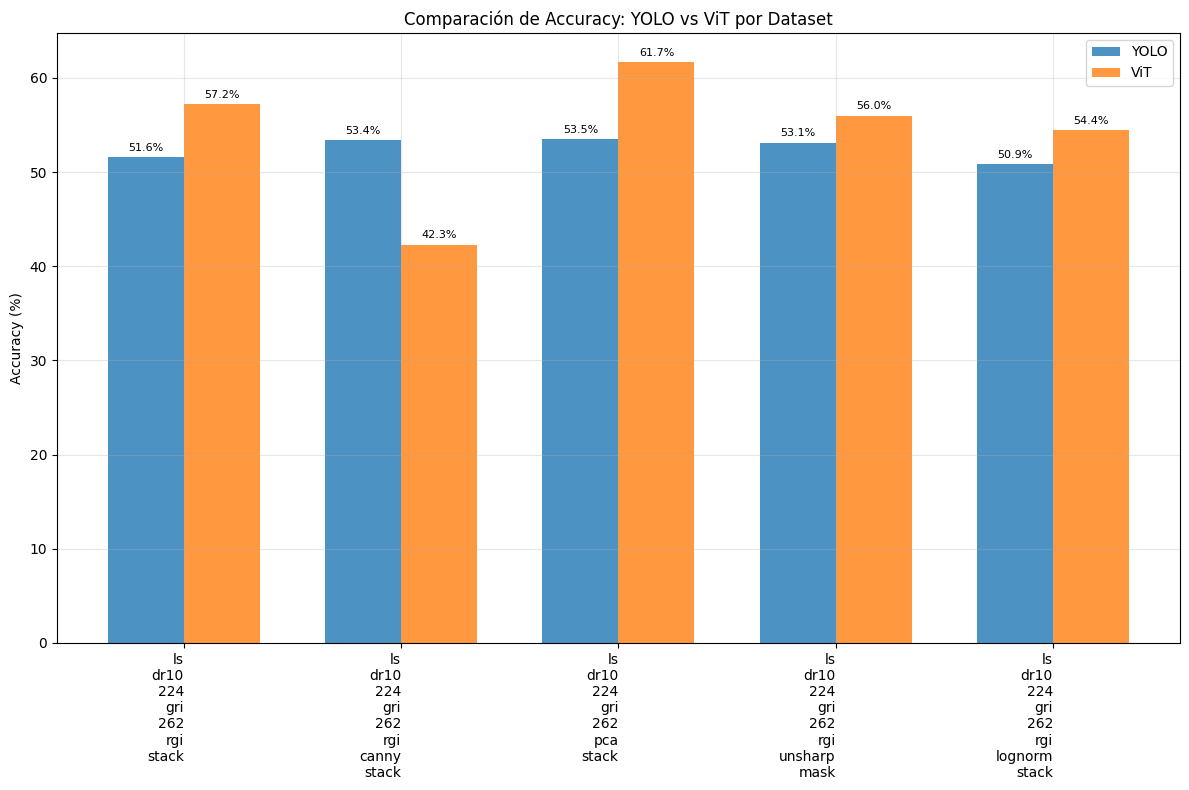

In [ ]:
# Comparación de resultados
print("=== COMPARACIÓN DE MODELOS ===")
# Obtener los mejores resultados de YOLO
if results:
    best_dataset = max(results.items(), key=lambda x: x[1]["best_val_acc"])[0]
    best_acc = results[best_dataset]["best_val_acc"]
else:
    print("No hay resultados de YOLO disponibles")
    best_dataset = "N/A"
    best_acc = 0.0

# Obtener los mejores resultados de ViT
if results_vit:
    best_dataset_vit = max(results_vit.items(), key=lambda x: x[1]["best_val_acc"])[0]
    best_acc_vit = results_vit[best_dataset_vit]["best_val_acc"]
else:
    print("No hay resultados de ViT disponibles")
    best_dataset_vit = "N/A"
    best_acc_vit = 0.0

print(f"YOLO - Mejor dataset: {best_dataset} | Precisión: {best_acc*100:.2f}%")
print(f"ViT  - Mejor dataset: {best_dataset_vit} | Precisión: {best_acc_vit*100:.2f}%")
print()

if best_acc_vit > best_acc:
    print(f"ViT supera a YOLO por {(best_acc_vit - best_acc)*100:.2f} puntos porcentuales")
elif best_acc > best_acc_vit:
    print(f"YOLO supera a ViT por {(best_acc - best_acc_vit)*100:.2f} puntos porcentuales")
else:
    print("Ambos modelos tienen el mismo rendimiento")

# Gráfica comparativa por dataset
datasets_comparison = []
yolo_accuracies = []
vit_accuracies = []

for dataset in results.keys():
    if dataset in results_vit:
        datasets_comparison.append(dataset)
        yolo_accuracies.append(results[dataset]["best_val_acc"] * 100)
        vit_accuracies.append(results_vit[dataset]["best_val_acc"] * 100)

if datasets_comparison:
    x = np.arange(len(datasets_comparison))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 8))
    rects1 = ax.bar(x - width/2, yolo_accuracies, width, label='YOLO', alpha=0.8)
    rects2 = ax.bar(x + width/2, vit_accuracies, width, label='ViT', alpha=0.8)
    
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Comparación de Accuracy: YOLO vs ViT por Dataset')
    ax.set_xticks(x)
    ax.set_xticklabels([d.replace('-', '\n') for d in datasets_comparison], ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Añadir valores en las barras
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                       xy=(rect.get_x() + rect.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)
    
    autolabel(rects1)
    autolabel(rects2)
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay datasets comunes para comparar")

## Conclusiones

El conjunto con unsharp mask (ls_dr10_224_gri_262_rgi_unsharp_mask) terminó siendo el más confiable: al resaltar bordes y contrastes separa con claridad galaxias con y sin anillos, sube el F1 de “ring” y fortalece el promedio ponderado. Los mapas de atención también confirman que el modelo mira justo donde debe.

Quedó claro que trabajar en binario (“none” vs “ring”) da mejores resultados que la versión multiclase: los F1 ponderados se mantienen arriba de 0.81, mientras que con cuatro etiquetas caen a 0.69–0.75. Menos etiquetas significa menos confusiones internas y más sensibilidad a los anillos reales.

Próximos pasos: Entrenar y evaluar con el dataset unsharp, sumar pruebas con arquitecturas como ViT y ResNet al pipeline de comparación, preparar un ensamble con los modelos más estables, ajustar hiperparámetros según el desempeño de esas variantes y comenzar el desarrollo del algoritmo de medición de anillos.